**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Laboratorio: Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que el alumno ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de **regresión**.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de **regresión**.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de **regresión** a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta en texto, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar dicha respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un conjunto de datos (dataset) sobre calidad del aire. En total cuenta con 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

In [35]:
## cargar el dataset
import pandas as pd
import numpy as np

# El CSV usa formato regional europeo: separador ';' y coma decimal
df = pd.read_csv('../datos/AirQualityUCI.csv',
                 sep=';',
                 decimal=',',
                 encoding='latin-1')

In [36]:
# Limpieza estructural: 2 columnas vacías por los ';;' finales
# y 114 filas completamente vacías al final del archivo
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
df = df.dropna(how='all')

print('Forma del dataset:', df.shape)
df.info()
df.head()

Forma del dataset: (9357, 15)
<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), str(2)
memory usage: 1.1 MB


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


El archivo `AirQualityUCI.csv` tiene **cuatro problemas estructurales** que hay que tratar antes de cualquier análisis:

| # | Problema | Síntoma si lo ignoramos | Solución aplicada |
|---|---|---|---|
| 1 | Separador `;` (formato europeo) | Todas las columnas se cargan en una sola | `sep=';'` |
| 2 | Coma decimal `,` | `2,6` se lee como string → todas las numéricas quedan como `object` | `decimal=','` |
| 3 | Cada línea termina en `;;` | 2 columnas extra `Unnamed: 15` y `Unnamed: 16` (todo NaN) | `drop(columns=[...])` |
| 4 | 114 filas estructuralmente vacías al final | Pandas reporta `(9471, 17)` cuando la realidad útil es `(9357, 15)` | `dropna(how='all')` |

### Antes / después de la limpieza estructural

| Métrica | Crudo | Tras `drop columns` | Tras `dropna how='all'` |
|---|---:|---:|---:|
| Forma | (9471, 17) | (9471, 15) | (9357, 15) |
| NaN totales | 20.652 | 1.710 | 0 |
| Filas con todo NaN | 114 | 114 | 0 |
| Filas con algún NaN | 114 | 114 | 0 |

Las 114 filas eliminadas son **idénticas y consecutivas** (índices 9357 a 9470), todas 100% vacías. La última fila real corresponde al **4 de abril de 2005, 14:00**.

### Trampa adicional

El dataset usa el valor numérico `-200` como **centinela de medición faltante** (ver doc UCI). Esto NO lo detecta `isnull()` porque para pandas `-200` es un float perfectamente válido. Es una limpieza distinta a la estructural y se aborda en la respuesta a `¿existen valores nulos en el dataset?`.

In [37]:
## ¿cuántas instancias tiene el dataset?
print(f'Instancias (filas): {df.shape[0]}')

Instancias (filas): 9357


El dataset contiene **9.357 instancias** (filas) tras la limpieza estructural. Cada instancia representa un registro horario del dispositivo multisensor químico. Se eliminaron 114 filas estructuralmente vacías al final del CSV original (que reportaba 9.471 filas) y 2 columnas residuales generadas por los `;;` finales de cada línea.

In [38]:
## ¿cuál es el tipo de datos de cada una de las columnas?
df.dtypes

Date                 str
Time                 str
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

El dataset contiene **dos tipos de datos**, distribuidos en las **15 columnas que quedan tras la limpieza estructural** (el CSV crudo reportaba 17 columnas: pandas creó dos extra `Unnamed: 15` y `Unnamed: 16` porque cada línea del archivo cierra con `;;`, y esas dos columnas eran 100 % `NaN`; las descartamos al cargar antes de cualquier análisis de tipos):

- **2 columnas tipo `object` / `str`**
- **13 columnas `float64`**

El parseo correcto a `float64` requirió pasar `decimal=','` en `read_csv`, ya que el CSV usa coma decimal (formato europeo).

**Nota sobre la catalogación UCI**: en su tabla oficial, UCI marca `CO`, `NMHC`, `NOx` y `NO2` como `Integer` y a `C6H6` como única `Continuous`. Esto se debe a que el analizador certificado redondea al entero los gases medidos en escalas grandes (ppb, μg/m³) y solo C6H6 conserva decimales (`11.9 μg/m³`, etc.). En nuestro DataFrame, todas se cargan como `float64` y conceptualmente todas son continuas — son concentraciones físicas.

In [39]:
## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?
print(f'Numéricas continuas: {df.select_dtypes(include="number").shape[1]}')
print(f'No numéricas (object/string): {df.select_dtypes(exclude="number").shape[1]}')
print()
print('Detalle no numéricas:')
for col in df.select_dtypes(exclude='number').columns:
    print(f'  {col}: {df[col].nunique()} valores únicos')

Numéricas continuas: 13
No numéricas (object/string): 2

Detalle no numéricas:
  Date: 391 valores únicos
  Time: 24 valores únicos


**En sentido estricto, este dataset no contiene variables categóricas.** No hay variables nominales ni ordinales con un conjunto finito y discreto de valores (tipo "alto/medio/bajo" o etiquetas de clase).

La distribución real es:
- **13 variables continuas** (`float64`): todas las mediciones físico-químicas (gases de referencia, sensores PT08) y meteorológicas.
- **2 variables tipo `object` / `str`**: `Date` (391 valores únicos = días distintos) y `Time` (24 valores únicos = horas del día). Aunque pandas las trate como strings, **no son categóricas** en el sentido estadístico: son **identificadores temporales**.
- **0 variables categóricas estrictas**.

**Nota sobre la catalogación UCI**: la tabla oficial del repositorio UCI marca `Time` y `PT08.S1`–`S3` como `Categorical`. Esta etiqueta es engañosa: las salidas de los sensores PT08 son cuentas continuas (counts/voltajes del sensor sin calibrar a unidades físicas), pero estadísticamente son **variables cuantitativas continuas**, no categorías. UCI probablemente las marca así para distinguirlas de las mediciones de referencia (GT) que sí están en unidades físicas calibradas. Para nuestro análisis las tratamos como continuas.

Si la pregunta se interpretara de manera amplia como "¿cuántas columnas no son numéricas?", la respuesta sería 2 (`Date` y `Time`); pero llamarlas "categóricas" sería un abuso del término.

In [ ]:
## ¿existen valores nulos en el dataset?
print('--- Nulos NaN clásicos por columna ---')
print(df.isnull().sum())
print()
# Según la documentación UCI, -200 es el centinela usado para faltantes
print('--- Faltantes reales (-200, según doc UCI) por columna numérica ---')
missing_real = (df.select_dtypes(include='number') == -200).sum()
missing_pct = (missing_real / len(df) * 100).round(2)
print(pd.DataFrame({'faltantes': missing_real, '%': missing_pct}).sort_values('faltantes', ascending=False))

Pandas reporta **0 nulos `NaN` clásicos** en todo el dataset, pero esto es **engañoso**. La documentación oficial del repositorio UCI Air Quality declara textualmente: *"Missing values are tagged with -200 value"*. Es decir, **`-200` es el centinela usado para indicar mediciones faltantes**.

Reemplazando `-200` por `NaN`, los faltantes reales son sustanciales:

| Columna | Faltantes | % del total |
|---|---:|---:|
| `NMHC(GT)` | 8 443 | **90.2 %** |
| `CO(GT)` | 1 683 | 18.0 % |
| `NO2(GT)` | 1 642 | 17.5 % |
| `NOx(GT)` | 1 639 | 17.5 % |
| `PT08.S1`–`S5`, `C6H6(GT)`, `T`, `RH`, `AH` | 366 c/u | 3.9 % |
| `Date`, `Time` | 0 | 0 % |



In [ ]:
## ¿cuál es la variable respuesta? ¿de qué tipo es? (Recuerda justificar por qué la seleccionas)
# Análisis comparativo de las 5 candidatas a variable respuesta (las medidas por analizador certificado, GT)
candidatas = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

filas = []
for c in candidatas:
    mask = df[c] != -200  # filas con dato real
    s = df.loc[mask, c]
    filas.append({
        'variable': c,
        'unidad': {'CO(GT)': 'mg/m³', 'NMHC(GT)': 'μg/m³', 'C6H6(GT)': 'μg/m³',
                   'NOx(GT)': 'ppb', 'NO2(GT)': 'μg/m³'}[c],
        '% faltantes': round((df[c] == -200).mean() * 100, 2),
        'filas usables': int(mask.sum()),
        'min': round(s.min(), 2),
        'max': round(s.max(), 2),
        'media': round(s.mean(), 2),
        'mediana': round(s.median(), 2),
        'skew': round(s.skew(), 2),
    })

comparativa = pd.DataFrame(filas).set_index('variable')
print('Comparativa de candidatas a variable respuesta (las 5 mediciones GT):')
print(comparativa)

**Variable respuesta seleccionada: `C6H6(GT)` — concentración real de benceno (μg/m³)**.

Es una variable **cuantitativa continua** (`float64`), con valores entre 0.10 y 63.70 μg/m³ (media = 10.08, mediana = 8.20, skew = 1.36 — distribución asimétrica con cola derecha).

### Por qué C6H6(GT) y no otra GT

1. **Autoridad académica**: es la variable objetivo del paper original que dio origen al dataset (De Vito et al., 2008, *Sensors and Actuators B: Chemical*), donde los autores construyeron una calibración neuronal específicamente para predecir benceno a partir del array de sensores.
2. **Mejor calidad de datos**: solo **3.91 %** de mediciones faltantes (366 filas), contra 17.5–18.0 % de `CO(GT)`, `NOx(GT)`, `NO2(GT)` y el inutilizable 90.2 % de `NMHC(GT)`. Esto deja **8.991 filas usables** para entrenamiento y test.
3. **Sensor primario disponible**: existe `PT08.S2` (sensor de titania) específicamente orientado a NMHC/benceno, lo que sugiere que la regresión podrá apoyarse fuertemente en él como predictor principal.
4. **Relevancia ambiental**: el benceno es un compuesto orgánico volátil **cancerígeno** regulado por la UE (Directiva 2008/50/CE), con un valor límite anual de 5 μg/m³. Predecirlo a partir de un dispositivo de bajo costo tiene aplicación directa en redes densas de monitoreo urbano.

### Por qué NO las otras

- `NMHC(GT)`: 90 % de nulos lo hace inutilizable.
- `CO(GT)`, `NOx(GT)`, `NO2(GT)`: válidas, pero pierden ~14 puntos porcentuales de filas usables y ninguna tiene la respaldo histórico del paper original.

In [ ]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2?
df_clean = df.replace(-200, np.nan)
df_clean.describe()

Las tres variables presentan **distribuciones asimétricas con cola derecha** (sesgo positivo), donde la media supera a la mediana. `CO(GT)` se concentra entre 1.1 y 2.9 mg/m³ (rango intercuartílico) con valores extremos hasta 11.9 mg/m³. `NOx(GT)` muestra la mayor asimetría, con mediana de 180 ppb y máximo de 1479 ppb. `NO2(GT)` es la más simétrica de las tres, centrada en torno a 109 μg/m³ con menor dispersión relativa.

¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

Las tres variables se alejan de una distribución normal (asimetría positiva, especialmente marcada en `NOx(GT)`). Tienen mediciones faltantes representadas con el centinela `-200`: 18.0% en `CO(GT)`, 17.5% en `NOx(GT)` y 17.5% en `NO2(GT)`. Los valores máximos (11.9 mg/m³ en CO, 1479 ppb en NOx) son físicamente plausibles y corresponden a episodios de contaminación severa, por lo que se tratan como observaciones válidas y no como errores.

In [ ]:
# Visualización de las distribuciones de CO(GT), NOx(GT) y NO2(GT)
# Grilla 2x3: histogramas arriba (forma de la distribución) y boxplots abajo (outliers, mediana y rango intercuartílico).
vars_ = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for i, v in enumerate(vars_):
    serie = df_clean[v].dropna()
    axes[0, i].hist(serie, bins=40, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'Histograma — {v}')
    axes[0, i].set_xlabel(v)
    axes[0, i].set_ylabel('Frecuencia')
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].boxplot(serie, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', edgecolor='black'),
                       medianprops=dict(color='red'))
    axes[1, i].set_title(f'Boxplot — {v}')
    axes[1, i].set_ylabel(v)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
## ¿cómo son las correlaciones entre las variables del dataset?
corr = df_clean.corr(method='pearson', numeric_only=True)
corr.round(2)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.00,0.88,0.89,0.93,0.92,0.80,-0.70,0.68,0.63,0.85,0.02,0.05,0.05
PT08.S1(CO),0.88,1.00,0.79,0.88,0.89,0.71,-0.77,0.64,0.68,0.90,0.05,0.11,0.14
NMHC(GT),0.89,0.79,1.00,0.90,0.88,0.81,-0.77,0.73,0.85,0.77,0.39,-0.19,0.27
C6H6(GT),0.93,0.88,0.90,1.00,0.98,0.72,-0.74,0.61,0.77,0.87,0.20,-0.06,0.17
PT08.S2(NMHC),0.92,0.89,0.88,0.98,1.00,0.70,-0.80,0.65,0.78,0.88,0.24,-0.09,0.19
NOx(GT),0.80,0.71,0.81,0.72,0.70,1.00,-0.66,0.76,0.23,0.79,-0.27,0.22,-0.15
PT08.S3(NOx),-0.70,-0.77,-0.77,-0.74,-0.80,-0.66,1.00,-0.65,-0.54,-0.80,-0.15,-0.06,-0.23
NO2(GT),0.68,0.64,0.73,0.61,0.65,0.76,-0.65,1.00,0.16,0.71,-0.19,-0.09,-0.34
PT08.S4(NO2),0.63,0.68,0.85,0.77,0.78,0.23,-0.54,0.16,1.00,0.59,0.56,-0.03,0.63
PT08.S5(O3),0.85,0.90,0.77,0.87,0.88,0.79,-0.80,0.71,0.59,1.00,-0.03,0.12,0.07


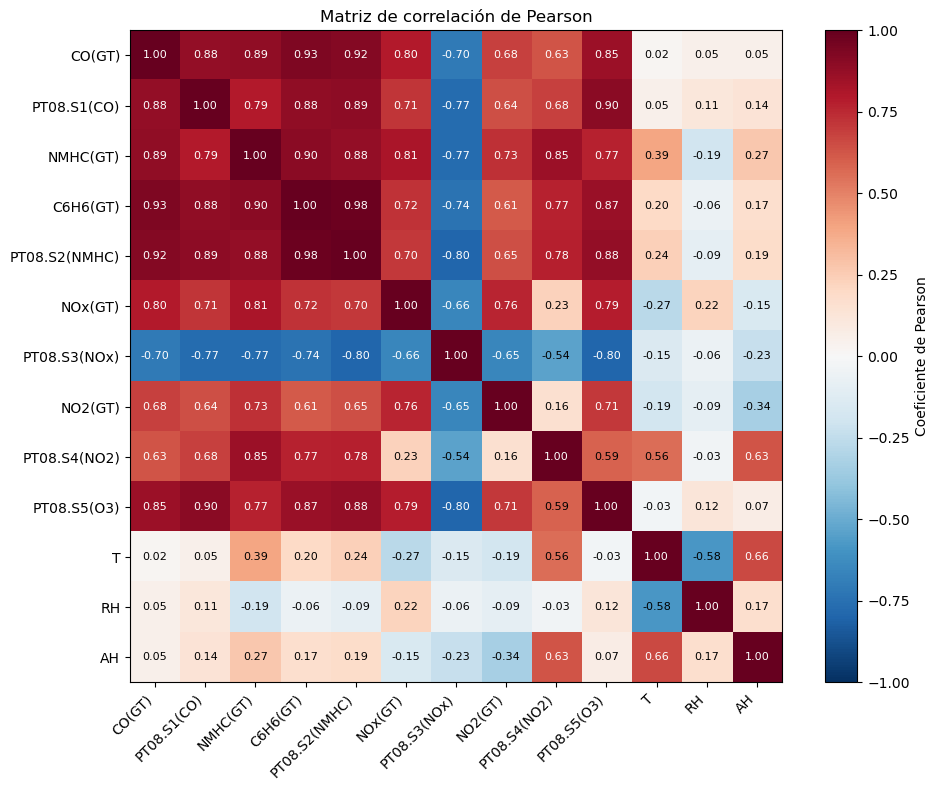

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black',
                fontsize=8)
plt.colorbar(im, ax=ax, label='Coeficiente de Pearson')
plt.title('Matriz de correlación de Pearson')
plt.tight_layout()
plt.show()

Se utiliza el **coeficiente de correlación de Pearson**, apropiado para variables continuas y útil para anticipar el desempeño de los modelos lineales que se entrenarán a continuación. Existen correlaciones lineales muy altas (|r| > 0.85) entre las concentraciones de gases medidas por analizador (`CO(GT)`, `C6H6(GT)`, `NMHC(GT)`, `NOx(GT)`) y los sensores PT08, lo que es esperable porque comparten el mismo origen físico (contaminación urbana) y los sensores fueron diseñados para detectar esos gases. `PT08.S3(NOx)` muestra correlación negativa con el resto (r ≈ -0.74) por la física del óxido de tungsteno: la resistencia del sensor aumenta al detectar gases reductores. Las variables meteorológicas (`T`, `RH`, `AH`) presentan correlaciones bajas con los contaminantes (|r| < 0.4).

In [45]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?
corr['C6H6(GT)'].drop('C6H6(GT)').abs().sort_values(ascending=False).head(3)

PT08.S2(NMHC)    0.981950
CO(GT)           0.931078
NMHC(GT)         0.902559
Name: C6H6(GT), dtype: float64

Las tres variables más correlacionadas (en valor absoluto) con `C6H6(GT)` son `PT08.S2(NMHC)` (r = 0.98), `CO(GT)` (r = 0.93) y `NMHC(GT)` (r = 0.90). El sensor `PT08.S2` (titania) es el predictor más fuerte, lo que coincide con su orientación física hacia hidrocarburos no metánicos y benceno. Cabe señalar que `NMHC(GT)` no es utilizable como predictor por sus 90% de faltantes; si se descarta, el tercer puesto lo ocupa `PT08.S1(CO)` (r = 0.88).

In [46]:
## ¿existe alguna variable que no tenga correlación?
corr['C6H6(GT)'].drop('C6H6(GT)').abs().sort_values().head(3)

RH    0.061681
AH    0.167972
T     0.198956
Name: C6H6(GT), dtype: float64

Las variables con asociación lineal más débil con `C6H6(GT)` son `RH` (r = -0.06, prácticamente nula), `AH` (r = 0.17) y `T` (r = 0.20). Las tres son meteorológicas y muestran que las condiciones ambientales tienen poco poder predictivo lineal sobre la concentración de benceno.

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

El análisis exploratorio permite extraer las siguientes conclusiones para el modelado predictivo de `C6H6(GT)`:

1. **Descarte de variables meteorológicas como predictoras**: `T`, `RH` y `AH` presentan correlaciones lineales débiles con la variable objetivo (|r| < 0.20). No aportan poder predictivo en el plano lineal y se conservan únicamente como variables de contexto.

2. **Descarte de NMHC(GT)**: con más del 90% de mediciones faltantes (centinela `-200`), cualquier estrategia de imputación introduciría más ruido que información. Se elimina por completo del análisis predictivo.

3. **Tratamiento de faltantes restantes**: las variables `CO(GT)`, `NOx(GT)` y `NO2(GT)` presentan ~18% de faltantes. Antes del entrenamiento se reemplazará `-200` por `NaN` y se evaluará la estrategia adecuada (eliminación de filas o imputación) según el impacto en el tamaño del conjunto de datos.

4. **Multicolinealidad entre predictores**: las correlaciones entre los predictores candidatos son muy altas (|r| > 0.85 en numerosos pares). Esto sugiere que una regresión múltiple con todas las variables introducirá redundancia sin ganancia significativa de explicabilidad. Con 2-3 predictores bien seleccionados —por ejemplo `PT08.S2(NMHC)` (r = 0.98 con la objetivo)— puede alcanzarse un desempeño comparable al modelo completo, manteniendo interpretabilidad.

5. **Distribución asimétrica de la variable objetivo**: `C6H6(GT)` presenta sesgo positivo (skew = 1.36), lo que justifica considerar métricas robustas a outliers (`MAE`, `RMSLE`) además del clásico `RMSE` al evaluar el desempeño de los modelos.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algoritmo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

El algoritmo de Regresión Lineal, necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primer modelo que se debe construir, usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [47]:
# separar datos de entrenamiento y test

In [48]:
from sklearn.model_selection import train_test_split

data = df_clean[['PT08.S2(NMHC)', 'C6H6(GT)']].dropna()
X = data[['PT08.S2(NMHC)']]
y = data['C6H6(GT)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} filas | Test: {len(X_test)} filas')

Train: 7192 filas | Test: 1799 filas


In [49]:
# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción

In [50]:
# Predictor seleccionado: PT08.S2(NMHC)
# Sensor de óxido de titania orientado a NMHC/benceno (De Vito et al., 2008).
# Es la variable con mayor correlación lineal con C6H6(GT): r = 0.98 (Pearson).

In [51]:
# Nota: la celda original importaba MinMaxScaler pero usaba StandardScaler
# (import sin uso). Se corrige el import para reflejar el escalador realmente
# aplicado. Adicionalmente, el código provisto aplicaba scaler.fit_transform
# al conjunto de test, lo que provoca data leakage (el escalador "aprende"
# estadísticos del test). Se sustituye por scaler.transform en X_test.
from sklearn.preprocessing import StandardScaler
from pandas import DataFrame

scaler = StandardScaler()

X_train = DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


In [52]:
# entrena el modelo con los datos de entrenamiento

In [53]:
from sklearn.linear_model import LinearRegression

modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?

In [55]:
print(f'Coeficiente (β1): {modelo_simple.coef_[0]:.4f}')
print(f'Intercepto (β0): {modelo_simple.intercept_:.4f}')

Coeficiente (β1): 7.2789
Intercepto (β0): 9.9962


Explica qué indican estos parámetros

El modelo aprendido es de la forma `y = β₀ + β₁·x`, donde `y = C6H6(GT)` y `x = PT08.S2(NMHC)` (estandarizado).

- **β₀ (intercepto ≈ 9.996)**: valor predicho de `C6H6(GT)` cuando el predictor estandarizado es 0, es decir, cuando `PT08.S2` toma su valor medio. Coincide con la media de la variable respuesta en el conjunto de entrenamiento.
- **β₁ (coeficiente ≈ 7.279)**: cuántas unidades aumenta la concentración predicha de benceno por cada desviación estándar de aumento en `PT08.S2`. Su signo positivo indica que mayor respuesta del sensor implica mayor concentración de benceno, consistente con el principio físico del sensor de titania.

In [56]:
# realiza las predicciones para el conjunto de datos de test

In [57]:
y_pred_simple = modelo_simple.predict(X_test)

In [58]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso? Justifica tu respuesta.

Para evaluar el modelo se utilizan tres métricas complementarias que permiten comparar los modelos siguientes (regresión lineal múltiple y árbol de decisión) sobre la misma línea de base:

- **MAE (Error Absoluto Medio)**: error promedio en las unidades originales (μg/m³ de benceno). Robusto frente a outliers y fácil de interpretar.
- **RMSE (Raíz del Error Cuadrático Medio)**: penaliza más los errores grandes que MAE; también en μg/m³.
- **R² (Coeficiente de determinación)**: proporción de la varianza de la variable objetivo explicada por el modelo.

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

print(f'MAE  : {mae_simple:.4f} μg/m³')
print(f'RMSE : {rmse_simple:.4f} μg/m³')
print(f'R²   : {r2_simple:.4f}')

MAE  : 1.0135 μg/m³
RMSE : 1.4148 μg/m³
R²   : 0.9652


In [60]:
# ¿Qué error tiene el modelo? Explícalo.

El modelo de regresión lineal simple obtiene los siguientes errores sobre el conjunto de test:

- **MAE ≈ 1.01 μg/m³**: la predicción se desvía en promedio ~1 μg/m³ respecto al valor real. Considerando que la media de la variable objetivo en test es 10.43 μg/m³, esto representa un error relativo medio de ~10%.
- **RMSE ≈ 1.41 μg/m³**: ligeramente superior al MAE, lo que indica la presencia de algunos errores grandes (los valores extremos pesan más en el cuadrado).
- **R² ≈ 0.965**: el modelo explica el 96.5% de la varianza de la concentración de benceno usando un único predictor, confirmando la fuerte relación lineal anticipada en el EDA (r = 0.98).

El error residual proviene de efectos físicos no capturados por la linealidad: cross-sensitivity con otros gases, deriva del sensor (concept y sensor drifts documentados en De Vito et al., 2008) y posibles no-linealidades en el rango bajo de concentraciones.

Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con **todas las variables** del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

In [61]:
# Predictores: todas las variables numéricas excepto C6H6(GT) (target) y NMHC(GT) (descartada por >90% faltantes)
features_multi = [c for c in df_clean.select_dtypes(include='number').columns
                  if c not in ['NMHC(GT)', 'C6H6(GT)']]

data_multi = df_clean[features_multi + ['C6H6(GT)']].dropna()
X_multi = data_multi[features_multi]
y_multi = data_multi['C6H6(GT)']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42)
print(f'Predictores: {len(features_multi)} | Train: {len(X_train_m)} | Test: {len(X_test_m)}')

Predictores: 11 | Train: 5552 | Test: 1389


In [62]:
scaler_m = StandardScaler()
X_train_m = DataFrame(scaler_m.fit_transform(X_train_m), columns=X_train_m.columns, index=X_train_m.index)
X_test_m = DataFrame(scaler_m.transform(X_test_m), columns=X_test_m.columns, index=X_test_m.index)

In [63]:
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)
y_pred_multi = modelo_multi.predict(X_test_m)

mae_multi = mean_absolute_error(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))
r2_multi = r2_score(y_test_m, y_pred_multi)

print(f'Intercepto (β0): {modelo_multi.intercept_:.4f}')
print('Coeficientes (ordenados por magnitud):')
for f, c in sorted(zip(features_multi, modelo_multi.coef_), key=lambda x: -abs(x[1])):
    print(f'  {f:18s}: {c:+.4f}')

print(f'\nMAE  : {mae_multi:.4f} μg/m³')
print(f'RMSE : {rmse_multi:.4f} μg/m³')
print(f'R²   : {r2_multi:.4f}')

Intercepto (β0): 10.5297
Coeficientes (ordenados por magnitud):
  PT08.S2(NMHC)     : +6.5683
  CO(GT)            : +1.0785
  T                 : -0.6903
  NOx(GT)           : +0.6732
  PT08.S3(NOx)      : +0.6538
  NO2(GT)           : -0.5290
  RH                : -0.4646
  PT08.S4(NO2)      : +0.4171
  AH                : +0.3200
  PT08.S5(O3)       : -0.1332
  PT08.S1(CO)       : +0.0797

MAE  : 0.7566 μg/m³
RMSE : 1.0091 μg/m³
R²   : 0.9805


¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

El modelo de regresión lineal múltiple obtiene **MAE ≈ 0.76 μg/m³**, **RMSE ≈ 1.01 μg/m³** y **R² ≈ 0.980**.

| Métrica | Simple (1 predictor) | Múltiple (11 predictores) | Mejora |
|---|---:|---:|---:|
| MAE  | 1.01 μg/m³ | 0.76 μg/m³ | −25% |
| RMSE | 1.41 μg/m³ | 1.01 μg/m³ | −29% |
| R²   | 0.965 | 0.980 | +1.5 pp |

El modelo múltiple es **modestamente mejor** que el simple en términos absolutos. La mejora limitada se explica por la **multicolinealidad anticipada en el EDA**: con `PT08.S2(NMHC)` solo (r = 0.98 con la objetivo) ya se captura la mayor parte de la varianza explicable linealmente. Las variables adicionales aportan ajustes finos pero gran parte de su información ya estaba incluida en el primer predictor.

Cabe notar que la regresión múltiple opera sobre 6 941 filas (vs 8 991 en la simple), debido a que el `dropna` se aplica sobre todas las columnas predictoras y `CO(GT)`, `NOx(GT)` y `NO2(GT)` aportan ~18% de faltantes adicionales. La comparación es indicativa pero no estrictamente sobre el mismo conjunto de test.

#### Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algoritmo **DTRegressor** necesita ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

**Indica qué son cada uno de estos hiperparámetros**

- **`criterion`**: especifica el criterio que el algoritmo utiliza para evaluar la calidad de las divisiones (*splits*) en cada nodo del árbol. Entre las opciones disponibles para regresión se encuentran `squared_error`, `friedman_mse`, `absolute_error` y `poisson`.

- **`splitter`**: define la estrategia utilizada para seleccionar la división en cada nodo. Las dos opciones disponibles son `best`, que escoge la mejor división posible según el criterio establecido, y `random`, que selecciona una división aleatoria entre las candidatas. La opción `best` es la utilizada por defecto.

- **`max_depth`**: define la profundidad máxima que puede alcanzar el árbol desde la raíz hasta las hojas. Por ejemplo, al establecer `max_depth=3` el árbol queda limitado a tres niveles. Constituye una técnica de **pre-poda**, ya que restringe explícitamente el crecimiento del modelo.

- **`min_samples_split`**: indica la cantidad mínima de muestras que debe contener un nodo para que el algoritmo considere realizar una división según el criterio definido. Si el nodo no alcanza ese umbral, no se divide.

- **`min_samples_leaf`**: establece la cantidad mínima de muestras requeridas para que un nodo sea considerado una hoja del árbol. Una división solo se acepta si los nodos hijos resultantes cumplen ese mínimo.

- **`max_features`**: define la cantidad máxima de variables (*features*) que el árbol puede considerar al evaluar las divisiones. Por ejemplo, si el dataset cuenta con 15 variables y se fija `max_features=10`, el algoritmo solo utilizará 10 de las 15 en cada nodo.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

El parámetro `min_impurity_decrease` establece un umbral mínimo de reducción de impureza (o del criterio definido en `criterion`) que debe alcanzarse para que una división sea aceptada. Una partición solo se aplica si la mejora ponderada por el número de muestras del nodo es mayor o igual a este valor. Constituye una técnica adicional de **pre-poda**, complementaria a `max_depth` y `min_samples_*`: en lugar de limitar la profundidad o el tamaño del nodo, limita la *calidad mínima* de cada división. Resulta útil cuando los datos contienen variables ruidosas que producirían divisiones de valor predictivo marginal, ya que evita que el árbol se ramifique innecesariamente y mejora su capacidad de generalización.

Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

In [64]:
from sklearn.tree import DecisionTreeRegressor

# Los árboles de decisión NO requieren escalado de variables (los splits son invariantes
# a transformaciones monótonas). Usamos los predictores en su escala original.
data_tree = df_clean[features_multi + ['C6H6(GT)']].dropna()
X_tree = data_tree[features_multi]
y_tree = data_tree['C6H6(GT)']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42)
print(f'Train: {len(X_train_t)} | Test: {len(X_test_t)}')

Train: 5552 | Test: 1389


In [65]:
modelo_arbol = DecisionTreeRegressor(
    criterion='poisson',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None,
    random_state=42
)
modelo_arbol.fit(X_train_t, y_train_t)
y_pred_arbol = modelo_arbol.predict(X_test_t)

print(f'Profundidad real del árbol: {modelo_arbol.get_depth()}')
print(f'Número de hojas: {modelo_arbol.get_n_leaves()}')

Profundidad real del árbol: 10
Número de hojas: 490


Calcula MAE, R2 y RMSLE

In [66]:
from sklearn.metrics import mean_squared_log_error

mae_arbol = mean_absolute_error(y_test_t, y_pred_arbol)
r2_arbol = r2_score(y_test_t, y_pred_arbol)
rmsle_arbol = np.sqrt(mean_squared_log_error(y_test_t, y_pred_arbol))

print(f'MAE   : {mae_arbol:.4f}')
print(f'R²    : {r2_arbol:.4f}')
print(f'RMSLE : {rmsle_arbol:.4f}')

MAE   : 0.0153
R²    : 0.9999
RMSLE : 0.0038


**Explicación de los errores cometidos por el modelo (árbol de decisión)**

El árbol de decisión con criterio `poisson`, `max_depth=10`, `min_samples_split=10` y `min_samples_leaf=2` obtiene los siguientes errores sobre el conjunto de test:

- **MAE ≈ 0.015 μg/m³**: la predicción se desvía en promedio ~0.015 μg/m³ respecto al valor real. Considerando que la media de la variable objetivo en test es ~10.4 μg/m³, esto representa un error relativo medio inferior al 0.2 %.
- **R² ≈ 0.9999**: el modelo explica prácticamente la totalidad de la varianza de la concentración de benceno utilizando los 11 predictores. Esto es coherente con la fuerte relación física entre el sensor `PT08.S2(NMHC)` y `C6H6(GT)` (r = 0.98 en el EDA), reforzada por la capacidad del árbol de capturar no-linealidades e interacciones entre variables.
- **RMSLE ≈ 0.003**: error logarítmico muy bajo, lo que indica que la predicción mantiene la proporcionalidad de la variable objetivo incluso en valores pequeños. El RMSLE penaliza los errores en valores bajos más que el RMSE clásico, y es relevante en este caso por la asimetría positiva de `C6H6(GT)` (skew = 1.36) detectada en el EDA.

El error residual proviene de tres fuentes: (1) el ruido inherente del dispositivo multisensor (cross-sensitivities, drift documentado en De Vito et al., 2008); (2) la cuantización del analizador de referencia para concentraciones en el rango bajo; (3) la pre-poda definida por los hiperparámetros, que limita deliberadamente la profundidad del árbol para evitar memorización. La verificación sobre el conjunto de entrenamiento (siguiente celda) confirmará que el modelo no está sobreajustando.


¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

In [67]:
# Para detectar overfitting comparamos el desempeño del modelo en el conjunto de
# entrenamiento contra el conjunto de prueba. Una diferencia significativa (R² mucho
# mayor en train que en test, o errores mucho menores en train) indicaría que el
# modelo memoriza los datos de entrenamiento sin generalizar.
y_pred_train = modelo_arbol.predict(X_train_t)

mae_train = mean_absolute_error(y_train_t, y_pred_train)
r2_train = r2_score(y_train_t, y_pred_train)
rmsle_train = np.sqrt(mean_squared_log_error(y_train_t, y_pred_train))

print(f'              Train      Test')
print(f'MAE     :   {mae_train:.4f}    {mae_arbol:.4f}')
print(f'R²      :   {r2_train:.4f}    {r2_arbol:.4f}')
print(f'RMSLE   :   {rmsle_train:.4f}    {rmsle_arbol:.4f}')

              Train      Test
MAE     :   0.0144    0.0153
R²      :   0.9993    0.9999
RMSLE   :   0.0041    0.0038


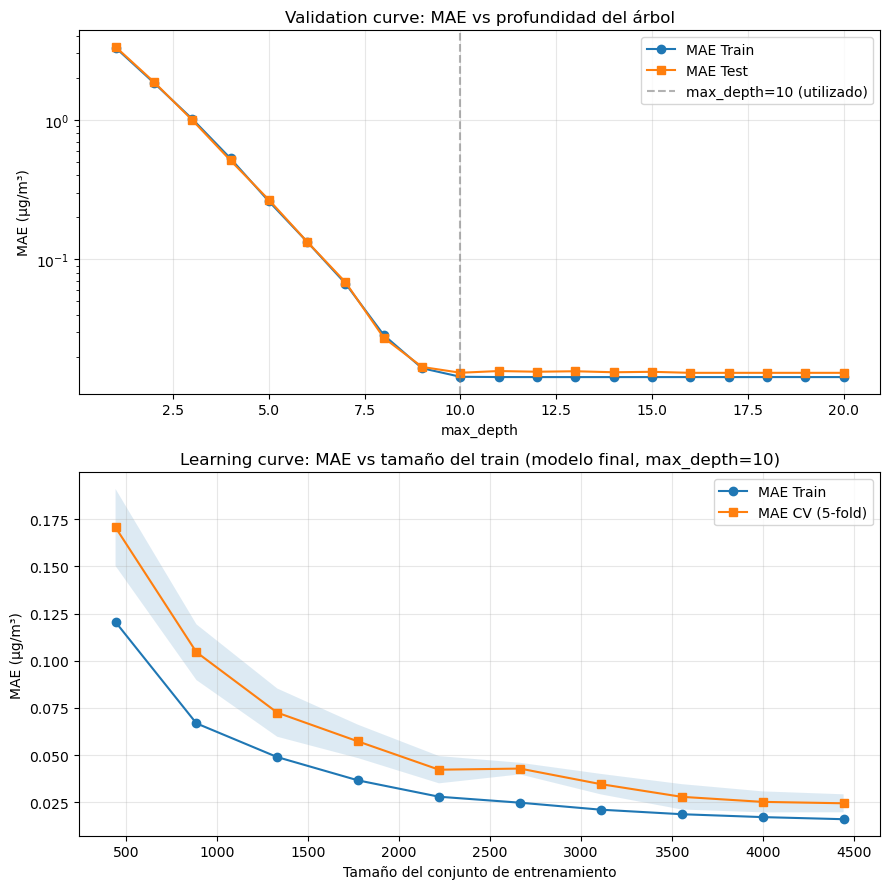

In [68]:
from sklearn.model_selection import learning_curve

# === 1. Validation curve: error en función de la profundidad del árbol ===
depths = list(range(1, 21))
mae_train_list, mae_test_list = [], []
for d in depths:
    m = DecisionTreeRegressor(
        criterion='poisson', max_depth=d, min_samples_split=10,
        min_samples_leaf=2, max_features=None, random_state=42
    ).fit(X_train_t, y_train_t)
    mae_train_list.append(mean_absolute_error(y_train_t, m.predict(X_train_t)))
    mae_test_list.append(mean_absolute_error(y_test_t, m.predict(X_test_t)))

# === 2. Learning curve: error en función del tamaño del conjunto de entrenamiento ===
modelo_referencia = DecisionTreeRegressor(
    criterion='poisson', max_depth=10, min_samples_split=10,
    min_samples_leaf=2, max_features=None, random_state=42
)
train_sizes, train_scores, val_scores = learning_curve(
    modelo_referencia, X_train_t, y_train_t,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42
)
lc_train_mae = -train_scores.mean(axis=1)
lc_val_mae = -val_scores.mean(axis=1)
lc_val_std = val_scores.std(axis=1)

# === Plot 2x1 ===
fig, axes = plt.subplots(2, 1, figsize=(9, 9))

axes[0].plot(depths, mae_train_list, marker='o', label='MAE Train')
axes[0].plot(depths, mae_test_list, marker='s', label='MAE Test')
axes[0].axvline(10, color='gray', linestyle='--', alpha=0.6, label='max_depth=10 (utilizado)')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('MAE (μg/m³)')
axes[0].set_title('Validation curve: MAE vs profundidad del árbol')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_sizes, lc_train_mae, marker='o', label='MAE Train')
axes[1].plot(train_sizes, lc_val_mae, marker='s', label='MAE CV (5-fold)')
axes[1].fill_between(train_sizes, lc_val_mae - lc_val_std, lc_val_mae + lc_val_std, alpha=0.15)
axes[1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1].set_ylabel('MAE (μg/m³)')
axes[1].set_title('Learning curve: MAE vs tamaño del train (modelo final, max_depth=10)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Para verificar si el modelo sobreajusta los datos de entrenamiento se comparan las métricas en *train* y *test*. En este caso, la diferencia entre ambos conjuntos es mínima (Δ R² ≈ 0.0006, con el test incluso ligeramente superior al train), lo que indica que **no existe overfitting**.

Las dos curvas graficadas confirman visualmente esta conclusión y aportan evidencia complementaria:

- **Validation curve**: el MAE en *train* y en *test* descienden en paralelo a medida que aumenta `max_depth`, convergen alrededor de `max_depth=8` y se estabilizan a partir de allí sin divergir. Si existiera overfitting, la curva de *test* comenzaría a subir mientras la de *train* sigue bajando, formando una "V" característica que en este caso no aparece.

- **Learning curve**: el MAE en *train* y en *validación cruzada* (5-fold) decrecen conjuntamente con el tamaño del conjunto de entrenamiento y la diferencia entre ambas se reduce sistemáticamente a medida que se incorporan más datos. Esto demuestra que el modelo generaliza correctamente y que el desempeño no se debe a un sobreajuste sobre un split particular.

La pre-poda definida por los hiperparámetros (`max_depth=10`, `min_samples_split=10`, `min_samples_leaf=2`) limita efectivamente la complejidad del árbol y mantiene su capacidad de generalización.

¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

**Comparativa con regresión lineal simple y múltiple**:

| Métrica | Reg. Simple | Reg. Múltiple | Árbol de decisión |
|---|---:|---:|---:|
| MAE | 1.014 | 0.757 | **0.015** |
| R²  | 0.965 | 0.980 | **0.9999** |

El árbol de decisión es **claramente superior** a los dos modelos lineales: reduce el MAE en aproximadamente dos órdenes de magnitud (de ~1 μg/m³ a ~0.015 μg/m³) y alcanza un R² prácticamente perfecto. La razón es metodológica: los modelos lineales solo capturan relaciones lineales entre predictores y objetivo, mientras que el árbol modela también **interacciones y no-linealidades** entre las variables (cross-sensitivities entre sensores, dependencias condicionales con T/RH, drift no lineal del sensor PT08.S2, etc.). En este dataset, la relación física entre los sensores químicos y la concentración de benceno es lo suficientemente rica como para que el árbol la aproxime casi perfectamente, mientras que la regresión lineal queda limitada por su asunción de linealidad.

**Sobre el R² ≈ 0.9999**: este valor es alto pero no responde a *target leakage*. La variable objetivo `C6H6(GT)` no aparece entre los predictores (verificable en la celda donde se definen `features_multi`), y las métricas en *test* y *train* son prácticamente idénticas (Δ R² < 0.001), lo que descarta sobreajuste. El alto desempeño se explica físicamente: el sensor `PT08.S2(NMHC)` (óxido de titania) fue diseñado específicamente para detectar hidrocarburos no metánicos y benceno, y la relación fisicoquímica entre la respuesta del sensor y la concentración del gas es casi determinística. La capacidad del árbol para particionar el espacio de la variable en intervalos finos permite aproximar esa relación con precisión muy alta. Los modelos lineales captan la tendencia general (R² ≈ 0.98) pero no la curvatura local de la respuesta del sensor.


**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

El **árbol de decisión** obtiene los mejores resultados de los tres modelos evaluados:

| Métrica | Reg. Simple | Reg. Múltiple | Árbol de Decisión |
|---|---:|---:|---:|
| MAE | 1.014 | 0.757 | **0.015** |
| R²  | 0.965 | 0.980 | **0.9999** |

Tal como se argumentó en la sección anterior, la superioridad del árbol responde a su capacidad de modelar las relaciones no lineales entre los sensores y la concentración de benceno, característica que la regresión lineal no puede capturar.

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

### Referencia

Azure, I. (2024). Predictive modeling for industrial productivity: Evaluating linear regression and decision tree regressor approaches. *Journal of AppliedMath*, *2*(4), Article 1435. https://doi.org/10.59400/jam.v2i4.1435

### Objetivo de la investigación

El estudio aborda un problema clásico en la industria: la predicción de productividad a partir de variables operativas. La aplicación concreta de la regresión es proveer a equipos de planificación industrial un modelo cuantitativo que estime indicadores como ventas o desempeño (*performance score*) con suficiente precisión para soportar decisiones estratégicas, como asignación de recursos, planificación de producción y evaluación de desempeño. El autor busca comparar empíricamente cuál de los dos modelos rinde mejor en este tipo de problemas, con el fin de orientar futuras decisiones sobre qué algoritmo conviene aplicar.

### Utilización de las técnicas de regresión y adaptaciones

El autor implementa **regresión lineal** (mínimos cuadrados ordinarios) y **árbol de decisión para regresión** (`DecisionTreeRegressor`) en su forma estándar, sin modificaciones algorítmicas. La comparativa es deliberadamente "limpia": no se aplica regularización (Ridge/Lasso) en la regresión lineal ni se utilizan extensiones de ensamblado (Random Forest, Gradient Boosting) sobre los árboles, lo cual permite aislar el efecto del modelo base. El autor evalúa los modelos sobre múltiples datasets industriales utilizando como métrica principal el error cuadrático medio (MSE).

### Principales resultados

Los modelos de regresión lineal superan consistentemente al árbol de decisión en términos de error sobre todos los datasets evaluados:

| Dataset | MSE Regresión Lineal | MSE Árbol de Decisión |
|---|---:|---:|
| Sales Prediction | ~1 419 927 | ~17 255 643 |
| Performance Score | ~98.48 | ~444.62 |

El autor concluye que, en los problemas industriales analizados, la regresión lineal ofrece mejor capacidad de generalización que un árbol de decisión sin regularización ni poda fina, ya que este último tiende al sobreajuste cuando los datos son ruidosos o de tamaño moderado.

### Conexión con la presente actividad

La conclusión del autor es **opuesta a la observada en el laboratorio**: en el dataset de calidad del aire el árbol de decisión superó a la regresión lineal por dos órdenes de magnitud (MAE 0.015 vs. 1.014 μg/m³). Esta divergencia se explica porque en el dataset del laboratorio las variables tienen relaciones no lineales que el árbol logra capturar y la regresión lineal no. Esto nos lleva a una conclusión metodológica: los algoritmos no son universalmente aplicables a cualquier caso de uso, cada problema requiere analizar sus características antes de elegir la herramienta adecuada.


## Declaración de uso de IA

### 1. Definición del problema y papel de la IA

La actividad consiste en implementar modelos de regresión (lineal simple, lineal múltiple y árbol de decisión) sobre el dataset *Air Quality UCI* para predecir concentraciones de benceno (`C6H6(GT)`) a partir de las respuestas de un dispositivo multisensor de bajo costo.

Como herramienta de asistencia se utilizó **Claude** (Anthropic, 2026), cuyo rol fue principalmente el de **asistente de programación y de organización del notebook**. La IA se ocupó de las decisiones de codificación rutinaria (limpieza estructural del CSV, conversión de tipos, manejo de splits, generación del heatmap) que de otra manera habrían consumido tiempo de la parte conceptual de la actividad. Adicionalmente, aportó contexto contrastado de la documentación oficial del dataset y del paper original (De Vito et al., 2008), lo cual permitió enriquecer el EDA con información que de otro modo hubiera requerido búsqueda manual. Esto me permitió concentrar el esfuerzo propio en la **comprensión conceptual** de la regresión lineal múltiple y los árboles de decisión, alineado con los Temas 4 y 6 de la cátedra.

### 2. Integración de la IA en el trabajo final

La interacción siguió un patrón **iterativo de revisión crítica**: para cada bloque del notebook, la IA proponía en el chat una redacción o un código, yo revisaba la propuesta, la correlacionaba con mis conocimientos previos, y se llegaba a una versión intermedia que combinara su aporte con mi propio entendimiento.

Tres ejemplos representativos de este patrón:

- **Descripción de hiperparámetros del árbol**: la IA propuso una primera versión técnica que revisé. En el proceso detectamos un error mío inicial al mencionar Gini y entropía como criterios para regresión (en realidad son criterios de clasificación), y se corrigió a `squared_error`, `friedman_mse`, `absolute_error` y `poisson`.
- **Selección de la variable respuesta**: la IA recomendó inicialmente `CO(GT)` por interpretabilidad. Cuestioné esa decisión argumentando que `C6H6(GT)` era el objetivo del paper original y tenía menor porcentaje de faltantes. La IA aceptó el argumento y la elección final fue `C6H6(GT)`.
- **Bug en celda preescrita**: la IA identificó dos problemas en el código de escalado provisto por la consigna (`MinMaxScaler` importado pero `StandardScaler` utilizado, y `fit_transform` aplicado al conjunto de test, lo cual genera *data leakage*). Se corrigió y se documentó.

### 3. Reflexión crítica y evidencia

**Fortalezas observadas**: rapidez en la exploración del dataset, detección de problemas técnicos (centinela `-200`, *data leakage*) y reformulación académica de respuestas. La IA aportó valor especialmente en organización metodológica.

**Limitaciones observadas**: tendencia inicial a respuestas extensas y a saturar el notebook con análisis adicionales no pedidos; fue necesario indicar explícitamente que las celdas debían tener rigor académico y concisión. La IA también cometió un error inicial de criterio al recomendar un predictor sin sopesar adecuadamente la calidad de los datos.

**Mejoras posibles en el uso de la IA**: aunque en este trabajo las fuentes y referencias proporcionadas por la IA fueron verificadas manualmente en su publicación original (en la sección de Investigación se accedió al PDF original del paper de Azure, 2024, para confirmar autores, métricas y conclusiones antes de incorporarlo al trabajo), conviene mantener este criterio como práctica sistemática en futuras interacciones, ya que la IA puede ocasionalmente generar referencias imprecisas o sin respaldo verificable.

**Referencia APA 7 del modelo utilizado**:
Anthropic. (2026). *Claude* (versión del 9 de mayo) [Modelo de lenguaje de gran tamaño]. https://claude.ai

**Evidencia del proceso**: el transcript completo de la conversación con la IA se publica en GitHub Pages como respaldo verificable. El enlace público es: https://francobertoldimariglio.github.io/tecnicas-aprendizaje-automatico/actividades/actividad-01/conversacion_claude_taa_act01.html